In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\danie\Documentos\Simulacoes COMSOL\otimizacao.txt",
    sep=r'\s{2,}',   # 2 ou mais espaços = separador
    engine='python',
    comment='%',
    header=None,
    names=['H(cm)','W(cm)', 'N_DC', 'N_AC', 'tempo(s)', 'B(T)', 'mur']
)

display(df)

,H(cm),W(cm),N_DC,N_AC,tempo(s),B(T),mur
0,25.0,3,350,4000,0.0,0.000014,1199.999269
1,25.0,3,350,4000,0.5,1.678399,117.565705
2,25.0,3,350,4000,1.0,2.174606,10.244823
3,25.0,3,350,4000,1.5,2.026732,21.610452
4,25.0,3,350,4000,2.0,1.559497,179.020544
...,...,...,...,...,...,...,...
175,30.0,5,400,5000,0.0,0.000009,1199.999269
176,30.0,5,400,5000,0.5,1.153339,652.002601
177,30.0,5,400,5000,1.0,2.013735,23.528701
178,30.0,5,400,5000,1.5,1.589766,164.327578


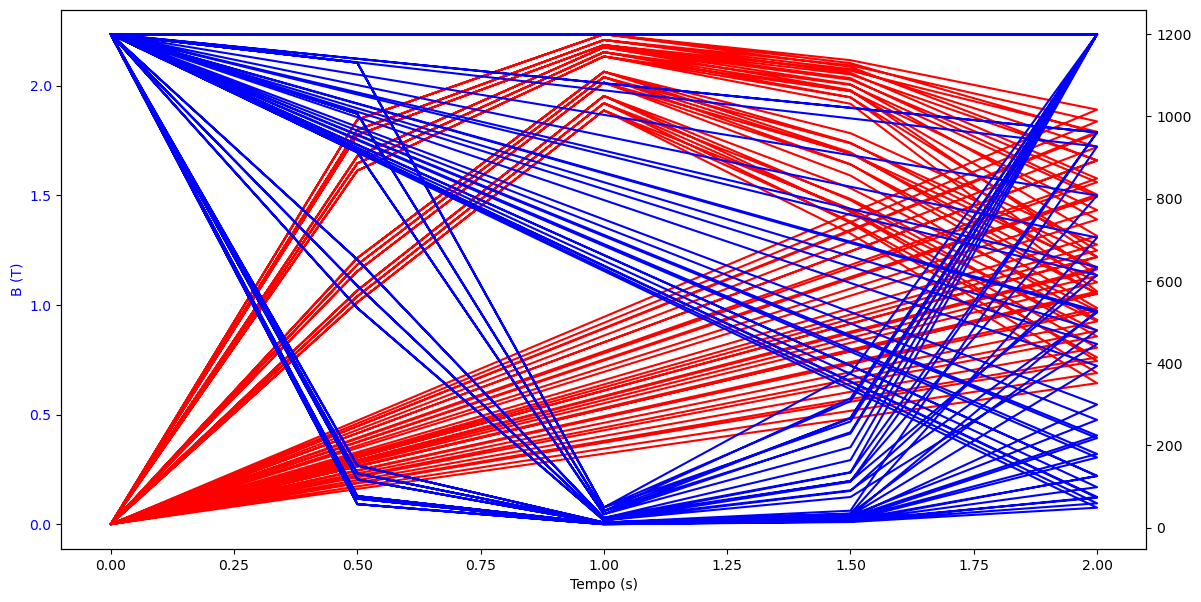

In [40]:
# Criar figura
fig, ax1 = plt.subplots(figsize=(14, 7))

# Eixo 1 (esquerda) → B
ax1.plot(df["tempo(s)"], df["B(T)"], c='red')
ax1.set_xlabel("Tempo (s)")
ax1.set_ylabel("B (T)", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# # Eixo 2 (direita) → μr
ax2 = ax1.twinx()
ax2.plot(df['tempo(s)'], df["mur"], c='blue')
# ax2.plot(df["H"][1:], mir[1:], c='red', label='μr')
# ax2.plot([0, max(df["H"].tolist())], [1, 1], c='green', linestyle='--')
# ax2.set_yscale('log')
# ax2.set_ylabel("μr (em escala logarítmica)", color='red')
# ax2.tick_params(axis='y', labelcolor='red')

# fig.legend(loc=10)
# plt.title('Curva B-H e Permeabilidade Magnética Relativa')
# plt.savefig(r"G:\Meu Drive\01 - Faculdade\TCC\python\Curva_B_H_Sem_Perdas_.png", dpi=300, bbox_inches="tight")
plt.show()

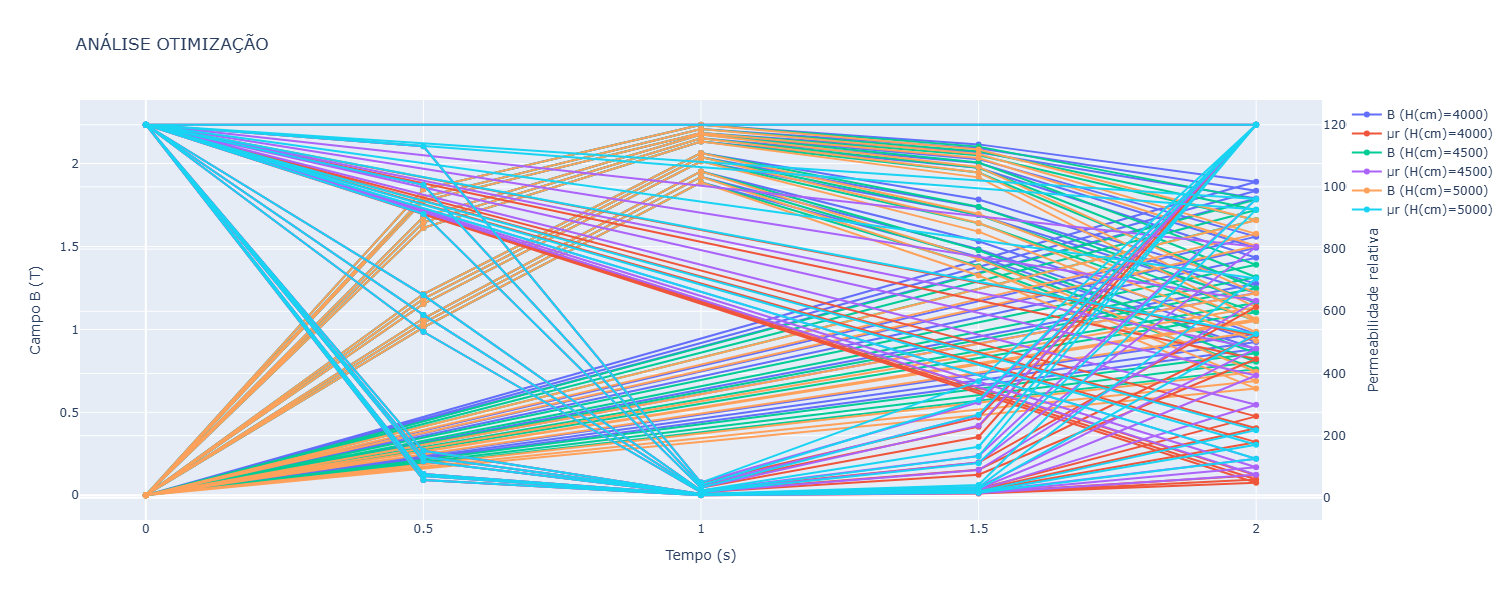

In [54]:
import pandas as pd
import plotly.graph_objects as go

# === CARREGAR DADOS ===
arquivo = r"C:\Users\danie\Documentos\Simulacoes COMSOL\otimizacao.txt"

df = pd.read_csv(
    arquivo,
    sep=r'\s{2,}',
    engine='python',
    comment='%',
    header=None,
    names=['H(cm)', 'tempo(s)', 'B(T)', 'mur']
)

# === DEFINIR PARÂMETROS ===
# Se tiver mais parâmetros (ex: W), adicione aqui
params = ['H(cm)']  # exemplo: ['H(cm)', 'W']

fig = go.Figure()

# === LOOP AUTOMÁTICO POR PARÂMETROS ===
for values, df_group in df.groupby(params):

    # garantir tupla
    if not isinstance(values, tuple):
        values = (values,)

    # criar label automático
    label = ', '.join([f'{p}={v}' for p, v in zip(params, values)])

    # 🔵 Campo B (eixo esquerdo)
    fig.add_trace(go.Scatter(
        x=df_group['tempo(s)'],
        y=df_group['B(T)'],
        mode='lines+markers',
        name=f'B ({label})',
        yaxis='y1'
    ))

    # 🔴 Permeabilidade (eixo direito)
    fig.add_trace(go.Scatter(
        x=df_group['tempo(s)'],
        y=df_group['mur'],
        mode='lines+markers',
        name=f'μr ({label})',
        yaxis='y2'
    ))

# === LAYOUT ===
fig.update_layout(
    title='ANÁLISE OTIMIZAÇÃO',
    xaxis=dict(title='Tempo (s)'),
    yaxis=dict(title='Campo B (T)', side='left'),
    yaxis2=dict(
        title='Permeabilidade relativa',
        overlaying='y',
        side='right'
    ),
    width=1500,
    height=600
)

fig.show()